# Unified Synthetic+Real Results Tables & Complete Statistical Test Catalogue

This notebook demonstrates the unified evaluation that loads pre-computed experiment results and produces:

- **A)** Method progression table (8 methods, synthetic vs real accuracy/arity)
- **B)** Spearman correlation between module recovery Jaccard and downstream accuracy
- **C)** Signed-vs-unsigned Hedges' g analysis with CoI signal divergence explanation
- **D)** Complete catalogue of 28 statistical tests (Friedman, Nemenyi, Wilcoxon, Hedges' g, Bayesian ROPE, correlations)

The evaluation covers 5 FIGS methods, 3 baselines, 8 real datasets, and 6 synthetic variants.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # scipy 1.16.3 requires Python >=3.11; use 1.15.3 for Python 3.10
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy, 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys

import numpy as np
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter7_unified_synthet/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation data: {list(data.keys())}")
print(f"Metadata keys: {list(data['metadata'].keys())}")
print(f"Metrics: {data['metrics_agg']}")

Loaded evaluation data: ['metadata', 'A_method_progression_table', 'B_recovery_accuracy_correlation', 'C_signed_vs_unsigned_narrative', 'D_statistical_test_catalogue', 'metrics_agg', 'datasets']
Metadata keys: ['evaluation_name', 'n_figs_methods', 'n_baseline_methods', 'n_real_datasets', 'n_classification_datasets', 'n_synthetic_variants', 'alpha', 'rope_width']
Metrics: {'axis_aligned_real_acc': 0.728185, 'signed_spectral_real_acc': 0.735609, 'signed_spectral_synth_acc_em': 0.6585, 'recovery_accuracy_spearman_rho': 0.046891, 'recovery_accuracy_spearman_p': 0.868203, 'signed_vs_unsigned_hedges_g_real': -0.420317, 'signed_vs_unsigned_hedges_g_synth': -0.465295, 'n_statistical_tests': 28, 'n_significant_tests': 8}


## Configuration

Statistical test parameters used in the evaluation.

In [5]:
# --- Tunable parameters ---
ALPHA = 0.05          # Significance level for hypothesis tests
ROPE = 0.01           # Region of practical equivalence width for Bayesian tests

# Method/dataset lists (from original evaluation)
FIGS_METHODS = ["axis_aligned", "random_oblique", "unsigned_spectral", "signed_spectral", "hard_threshold"]
BASELINE_METHODS = ["ebm", "random_forest", "linear"]
CLASSIFICATION_DATASETS = ["adult", "electricity", "eye_movements", "credit",
                           "higgs_small", "jannis", "miniboone"]

## Helper Functions

Core statistical helpers used in the evaluation: Hedges' g (bias-corrected effect size), Bayesian sign-test with ROPE, and safe Wilcoxon signed-rank test.

In [6]:
def hedges_g(x, y):
    """Compute Hedges' g (bias-corrected Cohen's d)."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        return float("nan")
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    s_pooled = math.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if s_pooled < 1e-15:
        return 0.0
    d = (np.mean(x) - np.mean(y)) / s_pooled
    correction = 1 - 3 / (4 * (n1 + n2) - 9)
    return float(d * correction)


def interpret_hedges_g(g):
    ag = abs(g)
    if ag < 0.2: return "negligible"
    if ag < 0.5: return "small"
    if ag < 0.8: return "medium"
    return "large"


def bayesian_sign_test_rope(diffs, rope=ROPE):
    """Simple Bayesian sign-test with ROPE."""
    diffs = np.asarray(diffs)
    n = len(diffs)
    if n == 0:
        return {"p_left": 0, "p_rope": 1, "p_right": 0}
    n_left = int(np.sum(diffs < -rope))
    n_rope = int(np.sum(np.abs(diffs) <= rope))
    n_right = int(np.sum(diffs > rope))
    total = n_left + n_rope + n_right
    if total == 0:
        return {"p_left": 0, "p_rope": 1, "p_right": 0}
    return {
        "p_left": round(n_left / total, 4),
        "p_rope": round(n_rope / total, 4),
        "p_right": round(n_right / total, 4),
    }


def safe_wilcoxon(x, y):
    """Wilcoxon signed-rank test handling ties and small n."""
    diffs = x - y
    nonzero = diffs[diffs != 0]
    if len(nonzero) < 3:
        return {"W": None, "p_value": 1.0, "n_nonzero": len(nonzero),
                "note": "Too few non-zero differences for Wilcoxon"}
    try:
        res = sp_stats.wilcoxon(x, y, alternative="two-sided")
        return {"W": float(res.statistic), "p_value": float(res.pvalue), "n_nonzero": len(nonzero)}
    except Exception as e:
        return {"W": None, "p_value": 1.0, "n_nonzero": len(nonzero), "note": str(e)[:200]}

print("Helper functions defined: hedges_g, interpret_hedges_g, bayesian_sign_test_rope, safe_wilcoxon")

# Quick demo of hedges_g
demo_x = np.array([0.75, 0.78, 0.72, 0.80, 0.76])
demo_y = np.array([0.70, 0.73, 0.68, 0.74, 0.71])
g = hedges_g(demo_x, demo_y)
print(f"Demo: hedges_g([0.75,0.78,...], [0.70,0.73,...]) = {g:.4f} ({interpret_hedges_g(g)})")

Helper functions defined: hedges_g, interpret_hedges_g, bayesian_sign_test_rope, safe_wilcoxon
Demo: hedges_g([0.75,0.78,...], [0.70,0.73,...]) = 1.6546 (large)


## Section A: Method Progression Table

Compares 5 FIGS methods + 3 baselines across synthetic and real datasets. Shows accuracy and split arity, with deltas relative to the axis-aligned baseline.

In [7]:
sec_a = data["A_method_progression_table"]
rows = sec_a["rows"]

# Display method progression table
headers = ["Method", "Synth Acc (E+M)", "Synth Arity", "Synth Acc (All6)", "Real Acc (7ds)", "Real Arity", "Delta Synth", "Delta Real"]
table_data = []
for r in rows:
    table_data.append([
        r["method"],
        f"{r['synth_acc_easy_medium']:.4f}" if r.get("synth_acc_easy_medium") is not None else "-",
        f"{r['synth_arity_easy_medium']:.2f}" if r.get("synth_arity_easy_medium") is not None else "-",
        f"{r['synth_acc_all6']:.4f}" if r.get("synth_acc_all6") is not None else "-",
        f"{r['real_acc_7ds']:.4f}" if r.get("real_acc_7ds") is not None else "-",
        f"{r['real_arity_7ds']:.2f}" if r.get("real_arity_7ds") is not None else "-",
        f"{r['delta_synth_vs_axis']:+.4f}" if r.get("delta_synth_vs_axis") is not None else "-",
        f"{r['delta_real_vs_axis']:+.4f}" if r.get("delta_real_vs_axis") is not None else "-",
    ])

print("=== Method Progression Table ===")
print(tabulate(table_data, headers=headers, tablefmt="grid"))
print(f"\nNarrative: {sec_a['narrative']}")

=== Method Progression Table ===
+-------------------+-------------------+---------------+--------------------+------------------+--------------+---------------+--------------+
| Method            | Synth Acc (E+M)   | Synth Arity   | Synth Acc (All6)   |   Real Acc (7ds) | Real Arity   | Delta Synth   |   Delta Real |
+===================+===================+===============+====================+==================+==============+===============+==============+
| axis_aligned      | 0.6846            | 1.00          | 0.6979             |           0.7282 | 1.00         | +0.0000       |       0      |
+-------------------+-------------------+---------------+--------------------+------------------+--------------+---------------+--------------+
| random_oblique    | 0.7448            | 2.43          | 0.7420             |           0.7319 | 3.30         | +0.0601       |       0.0037 |
+-------------------+-------------------+---------------+--------------------+------------------+------

## Section B: Recovery-Accuracy Correlation

Tests whether better module recovery (higher Jaccard similarity) correlates with better downstream classification accuracy. Uses Spearman correlation across variant-method pairs.

In [8]:
sec_b = data["B_recovery_accuracy_correlation"]

# Collect all (jaccard, accuracy_improvement) points across variants
all_jaccards = []
all_acc_imps = []
for vtable in sec_b["per_variant_tables"]:
    print(f"\nVariant: {vtable['variant']}")
    for row in vtable["rows"]:
        print(f"  {row['method']:25s}  Jaccard={row['jaccard']:.4f}  Acc improvement={row['accuracy_improvement']:+.4f}")
        all_jaccards.append(row["jaccard"])
        all_acc_imps.append(row["accuracy_improvement"])

# Recompute Spearman correlation to verify
if len(all_jaccards) >= 3:
    j = np.array(all_jaccards)
    a = np.array(all_acc_imps)
    rho, p = sp_stats.spearmanr(j, a)
    print(f"\nRecomputed Spearman: rho={rho:.4f}, p={p:.4f} (n={len(j)} points)")
    print(f"Original:           rho={sec_b['spearman_rho']:.4f}, p={sec_b['spearman_p']:.4f}")
print(f"\nInterpretation: {sec_b['interpretation']}")


Variant: easy_2mod_xor
  signed_spectral            Jaccard=1.0000  Acc improvement=-0.0437
  unsigned_spectral          Jaccard=1.0000  Acc improvement=+0.1236
  hard_threshold             Jaccard=1.0000  Acc improvement=+0.1244

Variant: medium_4mod_mixed
  signed_spectral            Jaccard=0.5000  Acc improvement=-0.0086
  unsigned_spectral          Jaccard=1.0000  Acc improvement=-0.0070
  hard_threshold             Jaccard=0.1429  Acc improvement=-0.0021

Variant: overlapping_modules
  signed_spectral            Jaccard=0.2857  Acc improvement=-0.0037
  unsigned_spectral          Jaccard=0.4000  Acc improvement=-0.0095
  hard_threshold             Jaccard=0.3000  Acc improvement=-0.0003

Variant: hard_4mod_unequal
  signed_spectral            Jaccard=0.2985  Acc improvement=+0.0554
  unsigned_spectral          Jaccard=0.4571  Acc improvement=+0.1142
  hard_threshold             Jaccard=0.1781  Acc improvement=+0.1035

Variant: highdim_8mod
  signed_spectral            Jaccard=0.

## Section C: Signed-vs-Unsigned Hedges' g Analysis

Compares signed spectral vs unsigned spectral methods using Hedges' g effect sizes on both real and synthetic data. Explains the divergence through CoI (Co-occurrence of Information) signal diagnostics.

In [9]:
sec_c = data["C_signed_vs_unsigned_narrative"]

# Summary statistics
print("=== Signed-vs-Unsigned Hedges' g Summary ===")
print(f"Real data:      g(accuracy)={sec_c['real_hedges_g_accuracy']:.4f}, g(arity)={sec_c['real_hedges_g_arity']:.4f}")
print(f"Synthetic data: g(accuracy)={sec_c['synthetic_hedges_g_accuracy']:.4f}, g(arity)={sec_c['synthetic_hedges_g_arity']:.4f}")

# Per-item breakdown
print("\n--- Per-item Hedges' g (accuracy) ---")
headers_c = ["Name", "Domain", "Signed Acc", "Unsigned Acc", "g(acc)", "Interpretation"]
table_c = []
for item in sec_c["per_item_breakdown"]:
    g_acc = item.get("hedges_g_acc")
    table_c.append([
        item["name"],
        item["domain"],
        f"{item['signed_acc_mean']:.4f}" if item.get("signed_acc_mean") is not None else "-",
        f"{item['unsigned_acc_mean']:.4f}" if item.get("unsigned_acc_mean") is not None else "-",
        f"{g_acc:.4f}" if g_acc is not None else "-",
        interpret_hedges_g(g_acc) if g_acc is not None else "-",
    ])
print(tabulate(table_c, headers=headers_c, tablefmt="grid"))

# CoI diagnostics
coi = sec_c.get("coi_diagnostics", {})
if coi.get("mean_abs_coi_synthetic") is not None:
    print(f"\nMean |CoI| on synthetic data: {coi['mean_abs_coi_synthetic']:.4f}")
print(f"\nDivergence explanation: {sec_c['divergence_explanation']}")

=== Signed-vs-Unsigned Hedges' g Summary ===
Real data:      g(accuracy)=-0.4203, g(arity)=-5.4010
Synthetic data: g(accuracy)=-0.4653, g(arity)=-1.0050

--- Per-item Hedges' g (accuracy) ---
+---------------------+-----------+--------------+----------------+----------+------------------+
| Name                | Domain    |   Signed Acc |   Unsigned Acc |   g(acc) | Interpretation   |
+=====================+===========+==============+================+==========+==================+
| adult               | real      |       0.7018 |         0.7013 |   0.0166 | negligible       |
+---------------------+-----------+--------------+----------------+----------+------------------+
| electricity         | real      |       0.7943 |         0.7912 |   0.7379 | medium           |
+---------------------+-----------+--------------+----------------+----------+------------------+
| eye_movements       | real      |       0.5815 |         0.5727 |   0.5062 | medium           |
+---------------------+-

## Section D: Statistical Test Catalogue

Complete catalogue of 28 statistical tests including Friedman, Nemenyi post-hoc, Wilcoxon signed-rank, Hedges' g effect sizes, Bayesian ROPE, and correlation tests.

In [10]:
sec_d = data["D_statistical_test_catalogue"]
tests = sec_d["tests"]

print(f"=== Statistical Test Catalogue: {sec_d['n_tests']} tests ===\n")

# Summary table of all tests
headers_d = ["Test ID", "Test Name", "p-value", "Effect Size", "Significant?"]
table_d = []
for t in tests:
    p_str = f"{t['p_value']:.6f}" if t.get("p_value") is not None else "-"
    es_str = f"{t['effect_size']:.4f}" if t.get("effect_size") is not None else "-"
    sig_str = "Yes" if t.get("significant_at_005") else "No"
    table_d.append([t["test_id"], t["test_name"], p_str, es_str, sig_str])

print(tabulate(table_d, headers=headers_d, tablefmt="grid"))

# Count by type
from collections import Counter
type_counts = Counter(t["test_name"] for t in tests)
print(f"\nTest types: {dict(type_counts)}")
n_sig = sum(1 for t in tests if t.get("significant_at_005"))
print(f"Significant at alpha={ALPHA}: {n_sig}/{len(tests)}")

=== Statistical Test Catalogue: 28 tests ===

+------------------------------------------------------------------------------+-----------------------------+-----------+---------------+----------------+
| Test ID                                                                      | Test Name                   | p-value   | Effect Size   | Significant?   |
+==============================================================================+=============================+===========+===============+================+
| D1_friedman_8methods                                                         | Friedman                    | 0.000003  | 0.7697        | Yes            |
+------------------------------------------------------------------------------+-----------------------------+-----------+---------------+----------------+
| D2_nemenyi_posthoc                                                           | Nemenyi post-hoc            | -         | -             | Yes            |
+-----------------

## Visualization

Key results plotted: (1) method accuracy comparison, (2) recovery-accuracy scatter, (3) Hedges' g effect sizes, (4) statistical test significance overview.

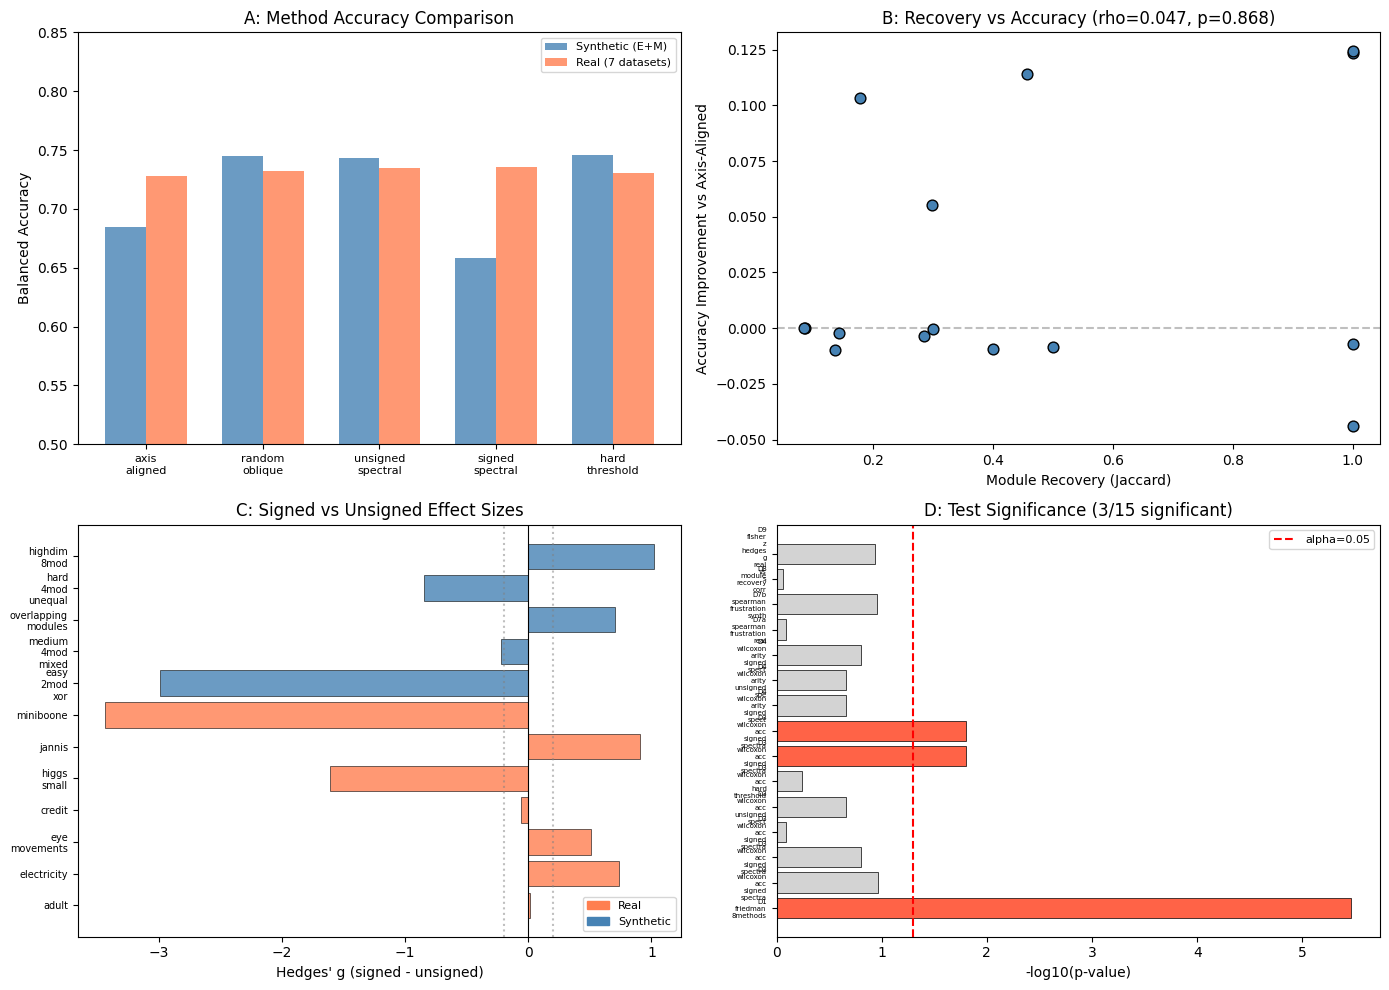

Saved evaluation_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Method Accuracy Comparison (Synthetic vs Real) ---
ax = axes[0, 0]
methods_with_synth = [r for r in rows if r.get("synth_acc_easy_medium") is not None]
method_names = [r["method"].replace("_", "\n") for r in methods_with_synth]
synth_accs = [r["synth_acc_easy_medium"] for r in methods_with_synth]
real_accs = [r["real_acc_7ds"] for r in methods_with_synth]
x_pos = np.arange(len(method_names))
width = 0.35
ax.bar(x_pos - width/2, synth_accs, width, label="Synthetic (E+M)", color="steelblue", alpha=0.8)
ax.bar(x_pos + width/2, real_accs, width, label="Real (7 datasets)", color="coral", alpha=0.8)
ax.set_ylabel("Balanced Accuracy")
ax.set_title("A: Method Accuracy Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=8)
ax.legend(fontsize=8)
ax.set_ylim(0.5, 0.85)

# --- Plot 2: Recovery-Accuracy Scatter ---
ax = axes[0, 1]
if all_jaccards and all_acc_imps:
    ax.scatter(all_jaccards, all_acc_imps, c="steelblue", edgecolors="black", s=60, zorder=3)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Module Recovery (Jaccard)")
    ax.set_ylabel("Accuracy Improvement vs Axis-Aligned")
    rho_val = sec_b.get("spearman_rho", 0)
    p_val = sec_b.get("spearman_p", 1)
    ax.set_title(f"B: Recovery vs Accuracy (rho={rho_val:.3f}, p={p_val:.3f})")
else:
    ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("B: Recovery vs Accuracy")

# --- Plot 3: Hedges' g Effect Sizes (Signed vs Unsigned) ---
ax = axes[1, 0]
items_with_g = [item for item in sec_c["per_item_breakdown"] if item.get("hedges_g_acc") is not None]
if items_with_g:
    names = [item["name"].replace("_", "\n") for item in items_with_g]
    g_vals = [item["hedges_g_acc"] for item in items_with_g]
    domains = [item["domain"] for item in items_with_g]
    colors = ["coral" if d == "real" else "steelblue" for d in domains]
    y_pos = np.arange(len(names))
    ax.barh(y_pos, g_vals, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.axvline(x=-0.2, color="gray", linestyle=":", alpha=0.5, label="Small effect threshold")
    ax.axvline(x=0.2, color="gray", linestyle=":", alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xlabel("Hedges' g (signed - unsigned)")
    ax.set_title("C: Signed vs Unsigned Effect Sizes")
    # Legend for domains
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="coral", label="Real"), Patch(color="steelblue", label="Synthetic")],
              fontsize=8, loc="lower right")

# --- Plot 4: Statistical Test Significance Overview ---
ax = axes[1, 1]
test_names_short = []
p_values = []
significances = []
for t in tests:
    if t.get("p_value") is not None:
        test_names_short.append(t["test_id"].replace("_", "\n")[:30])
        p_values.append(t["p_value"])
        significances.append(t.get("significant_at_005", False))

if p_values:
    # Plot -log10(p) for each test
    neg_log_p = [-math.log10(max(p, 1e-20)) for p in p_values]
    colors_p = ["tomato" if s else "lightgray" for s in significances]
    y_pos = np.arange(len(test_names_short))
    ax.barh(y_pos, neg_log_p, color=colors_p, edgecolor="black", linewidth=0.5)
    ax.axvline(x=-math.log10(ALPHA), color="red", linestyle="--", label=f"alpha={ALPHA}")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(test_names_short, fontsize=5)
    ax.set_xlabel("-log10(p-value)")
    ax.set_title(f"D: Test Significance ({sum(significances)}/{len(significances)} significant)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved evaluation_results.png")

## Summary Metrics

In [12]:
metrics = data["metrics_agg"]
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:45s} = {v:.6f}")
    else:
        print(f"  {k:45s} = {v}")
print("=" * 60)
print(f"\nKey findings:")
print(f"  - Signed spectral real acc: {metrics.get('signed_spectral_real_acc', 'N/A')}")
print(f"  - Axis-aligned real acc:    {metrics.get('axis_aligned_real_acc', 'N/A')}")
ss = metrics.get('signed_spectral_real_acc')
aa = metrics.get('axis_aligned_real_acc')
if ss is not None and aa is not None:
    print(f"  - Improvement:              {ss - aa:+.4f}")
print(f"  - Recovery-accuracy rho:    {metrics.get('recovery_accuracy_spearman_rho', 'N/A')} (p={metrics.get('recovery_accuracy_spearman_p', 'N/A')})")
print(f"  - Hedges g (real):          {metrics.get('signed_vs_unsigned_hedges_g_real', 'N/A')}")
print(f"  - Hedges g (synthetic):     {metrics.get('signed_vs_unsigned_hedges_g_synth', 'N/A')}")
print(f"  - Statistical tests:        {metrics.get('n_significant_tests', 0)}/{metrics.get('n_statistical_tests', 0)} significant")

EVALUATION SUMMARY
  axis_aligned_real_acc                         = 0.728185
  signed_spectral_real_acc                      = 0.735609
  signed_spectral_synth_acc_em                  = 0.658500
  recovery_accuracy_spearman_rho                = 0.046891
  recovery_accuracy_spearman_p                  = 0.868203
  signed_vs_unsigned_hedges_g_real              = -0.420317
  signed_vs_unsigned_hedges_g_synth             = -0.465295
  n_statistical_tests                           = 28
  n_significant_tests                           = 8

Key findings:
  - Signed spectral real acc: 0.735609
  - Axis-aligned real acc:    0.728185
  - Improvement:              +0.0074
  - Recovery-accuracy rho:    0.046891 (p=0.868203)
  - Hedges g (real):          -0.420317
  - Hedges g (synthetic):     -0.465295
  - Statistical tests:        8/28 significant
